# 02. Data Quality Assessment
Kiểm tra chất lượng dữ liệu: missing values, outliers, data types, price relationships.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv('../data/processed/combined_tiki_data.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (41576, 19)


## Missing Values Analysis

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

print("Missing values per column:")
print(missing_df[missing_df['Missing_Count'] > 0])

Missing values per column:
                  Missing_Count  Missing_Percentage
brand                         2                 0.0
fulfillment_type              1                 0.0


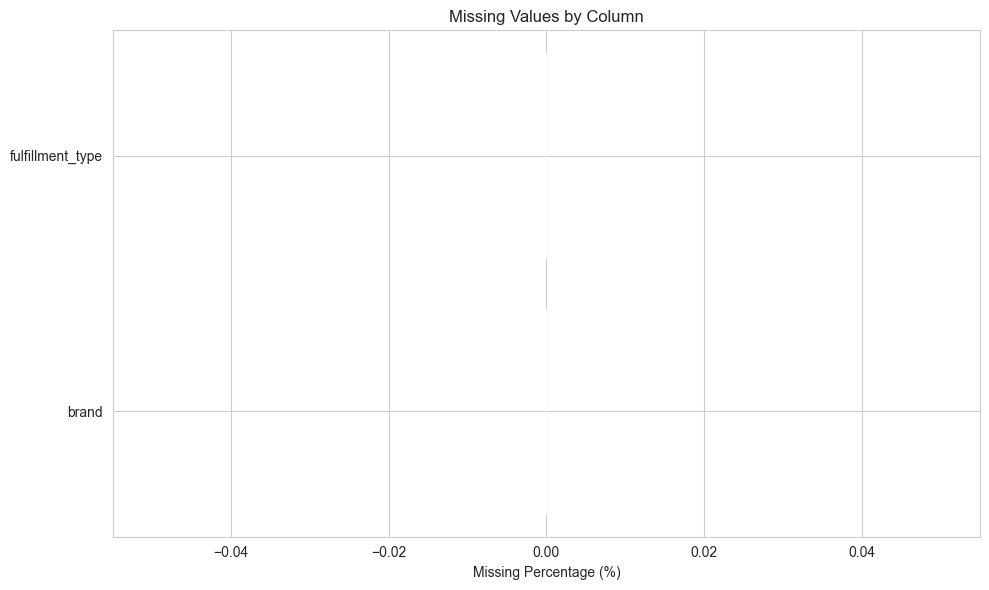

In [4]:
plt.figure(figsize=(10, 6))
missing_cols = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_cols) > 0:
    plt.barh(missing_cols.index, missing_cols['Missing_Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")

## Numerical Columns Statistics

In [5]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {numerical_cols}")
df[numerical_cols].describe()

Numerical columns: ['Unnamed: 0', 'id', 'original_price', 'price', 'review_count', 'rating_average', 'favourite_count', 'date_created', 'number_of_images', 'vnd_cashback', 'quantity_sold']


,Unnamed: 0,id,original_price,price,review_count,rating_average,favourite_count,date_created,number_of_images,vnd_cashback,quantity_sold
count,41576.000000,4.157600e+04,4.157600e+04,4.157600e+04,41576.000000,41576.000000,41576.0,41576.000000,41576.000000,41576.000000,41576.000000
mean,4686.068020,1.465187e+08,3.049790e+05,2.723589e+05,3.112084,1.381545,0.0,711.186117,5.969093,1431.424836,17.776939
std,4078.821167,6.365429e+07,8.518988e+05,7.630026e+05,18.231025,2.105277,0.0,6275.529624,3.455423,6388.980325,168.379391
min,0.000000,1.599010e+05,0.000000e+00,0.000000e+00,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.000000
25%,1732.000000,1.020968e+08,4.000000e+04,3.900000e+04,0.000000,0.000000,0.0,396.750000,4.000000,0.000000,0.000000
50%,3466.000000,1.523477e+08,9.000000e+04,8.500000e+04,0.000000,0.000000,0.0,616.000000,6.000000,0.000000,0.000000
75%,5765.250000,1.935654e+08,2.400000e+05,2.100000e+05,1.000000,4.000000,0.0,831.000000,8.000000,0.000000,5.000000
max,16018.000000,2.633026e+08,1.980000e+07,1.980000e+07,969.000000,5.000000,0.0,738076.000000,70.000000,167720.000000,24847.000000


## Price Validation

In [6]:
# Kiểm tra price <= original_price
invalid_prices = df[df['price'] > df['original_price']]
print(f"Products with price > original_price: {len(invalid_prices)}")

if len(invalid_prices) > 0:
    print("\nSample invalid prices:")
    print(invalid_prices[['id', 'name', 'price', 'original_price']].head())

Products with price > original_price: 0


In [7]:
# Tính discount percentage
df['discount_pct'] = ((df['original_price'] - df['price']) / df['original_price'] * 100).round(2)
df['has_discount'] = df['discount_pct'] > 0

print(f"Products with discount: {df['has_discount'].sum()} ({df['has_discount'].mean()*100:.1f}%)")
print(f"\nDiscount statistics:")
print(df[df['has_discount']]['discount_pct'].describe())

Products with discount: 9077 (21.8%)

Discount statistics:
count    9077.000000
mean       26.593637
std        17.581477
min         0.620000
25%        10.000000
50%        27.140000
75%        41.180000
max        88.570000
Name: discount_pct, dtype: float64


## Outlier Detection

In [8]:
# Phát hiện outliers bằng IQR method cho các cột quan trọng
key_cols = ['price', 'quantity_sold', 'rating_average', 'review_count']

for col in key_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

price: 4912 outliers (11.8%)
quantity_sold: 6442 outliers (15.5%)
rating_average: 0 outliers (0.0%)
review_count: 6535 outliers (15.7%)


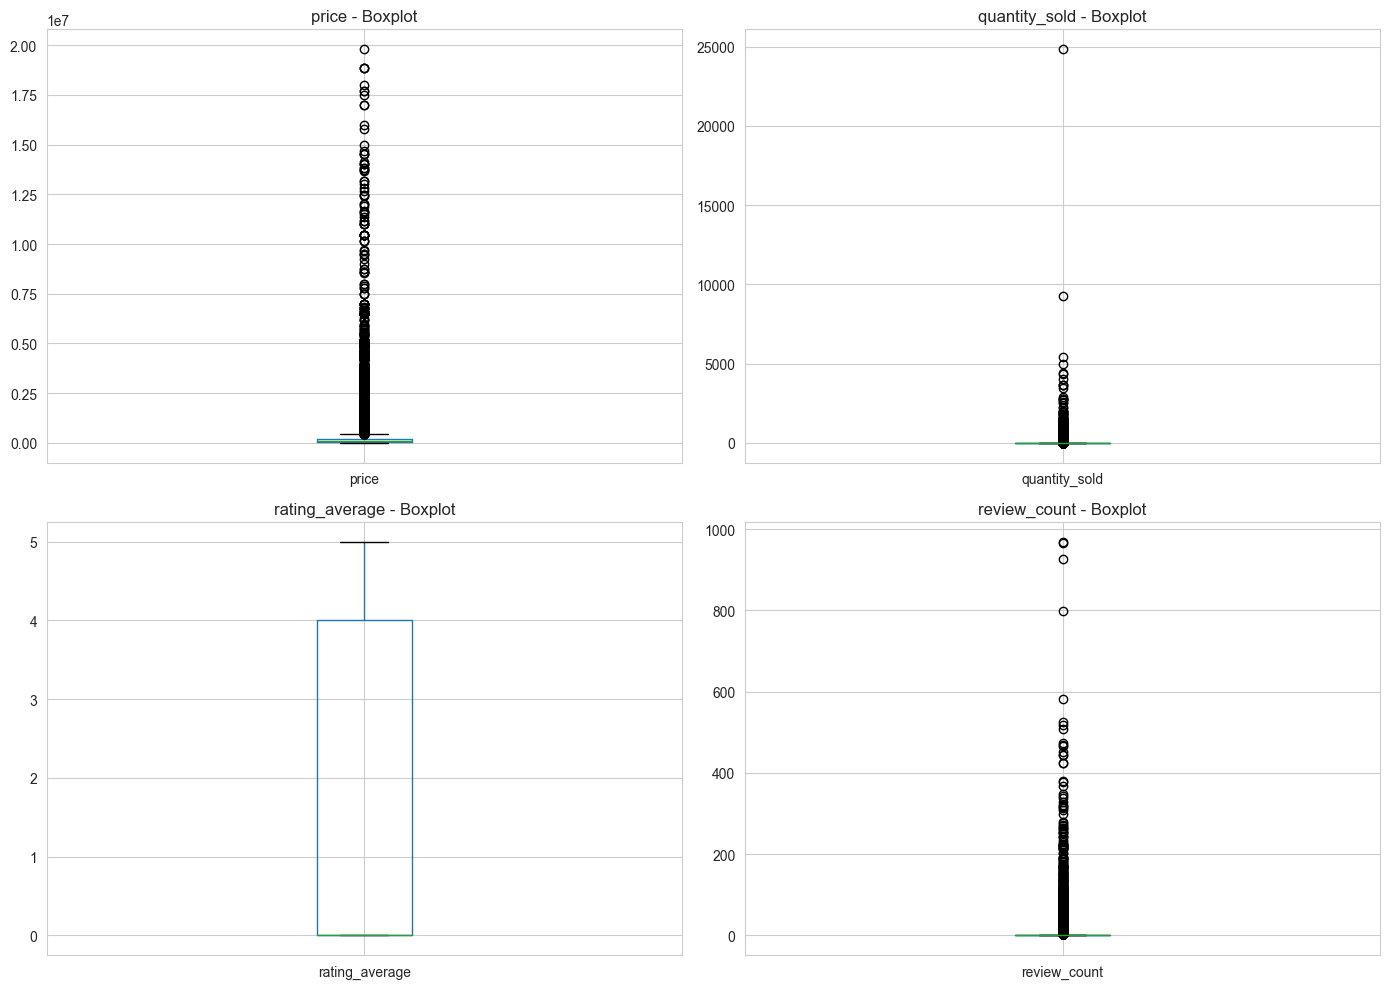

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, col in enumerate(key_cols):
    if col in df.columns:
        ax = axes[idx//2, idx%2]
        df.boxplot(column=col, ax=ax)
        ax.set_title(f'{col} - Boxplot')
plt.tight_layout()
plt.show()

## Data Type Consistency

In [10]:
print("Data types:")
print(df.dtypes)
print("\nUnique values in categorical columns:")
categorical_cols = ['fulfillment_type', 'pay_later', 'has_video', 'category']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(df[col].value_counts())

Data types:
Unnamed: 0            int64
id                    int64
name                 object
description          object
original_price        int64
price                 int64
fulfillment_type     object
brand                object
review_count          int64
rating_average      float64
favourite_count       int64
pay_later              bool
current_seller       object
date_created          int64
number_of_images      int64
vnd_cashback          int64
has_video              bool
category             object
quantity_sold         int64
discount_pct        float64
has_discount           bool
dtype: object

Unique values in categorical columns:

fulfillment_type: 4 unique values
fulfillment_type
dropship            40664
tiki_delivery         708
seller_delivery       202
instant_delivery        1
Name: count, dtype: int64

pay_later: 2 unique values
pay_later
False    23086
True     18490
Name: count, dtype: int64

has_video: 2 unique values
has_video
False    37305
True      4271
Nam

## Summary

In [11]:
quality_summary = {
    'total_rows': len(df),
    'total_columns': len(df.columns),
    'missing_values': df.isnull().sum().sum(),
    'duplicate_ids': df.duplicated(subset=['id']).sum(),
    'invalid_prices': len(invalid_prices),
    'products_with_discount': df['has_discount'].sum(),
    'avg_discount_pct': df[df['has_discount']]['discount_pct'].mean()
}

print("\n=== Data Quality Summary ===")
for key, value in quality_summary.items():
    print(f"{key}: {value}")


=== Data Quality Summary ===
total_rows: 41576
total_columns: 21
missing_values: 4
duplicate_ids: 0
invalid_prices: 0
products_with_discount: 9077
avg_discount_pct: 26.593636664096064
